# Customer Churn Analysis
Exploratory Data Analysis on Telecom Customer Churn Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\ML_learn\Telco_Customer_Churn\Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Missing Values Check

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Convert TotalCharges to Numeric

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
df['TotalCharges'].isnull().sum()

11

In [16]:
df = df.dropna()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [19]:
# Churn Distribution
# Most customers have not churned compared to those who left the service.

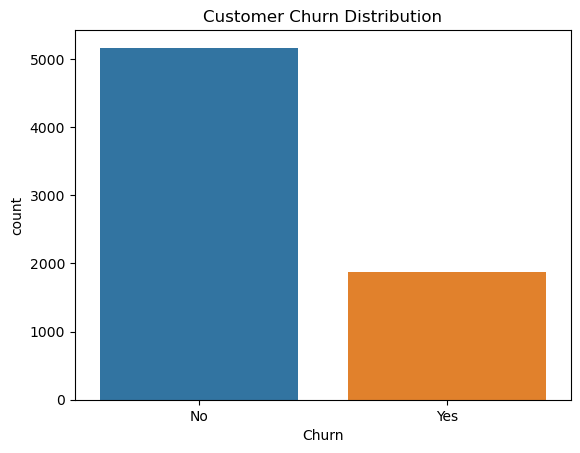

In [46]:
sns.countplot(x='Churn',data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [22]:
# Churn vs Contract Type
# Customers with month-to-month contracts show higher churn rates.

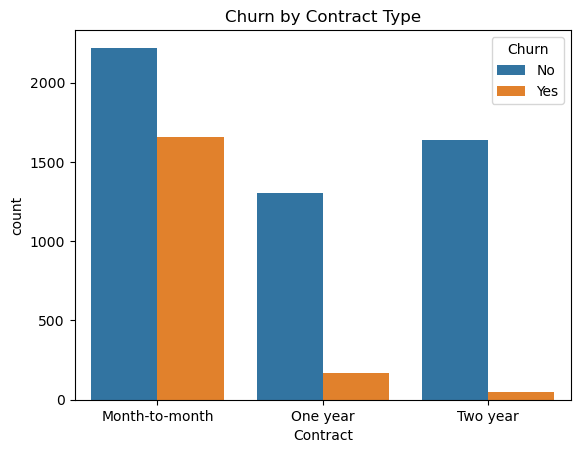

In [25]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title("Churn by Contract Type")
plt.show()

In [26]:
# Churn vs Payment Method
# Electronic check payment method has higher churn compared to others.

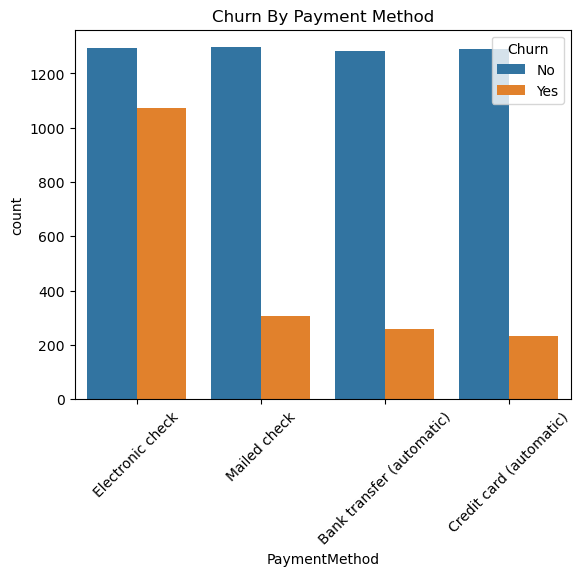

In [47]:
sns.countplot(x='PaymentMethod',hue='Churn',data=df)
plt.xticks(rotation=45)
plt.title("Churn By Payment Method")
plt.show()

In [30]:
# Monthly Charges Distribution
# Monthly charges vary widely among customers.

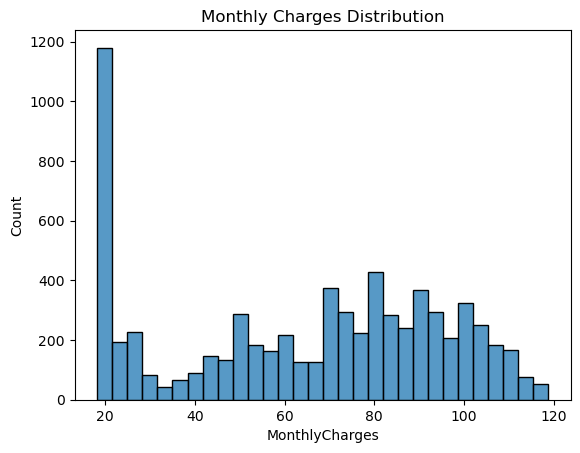

In [32]:
sns.histplot(df['MonthlyCharges'],bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

In [33]:
# Churn vs Monthly Charges
# Customers with higher monthly charges are more likely to churn.

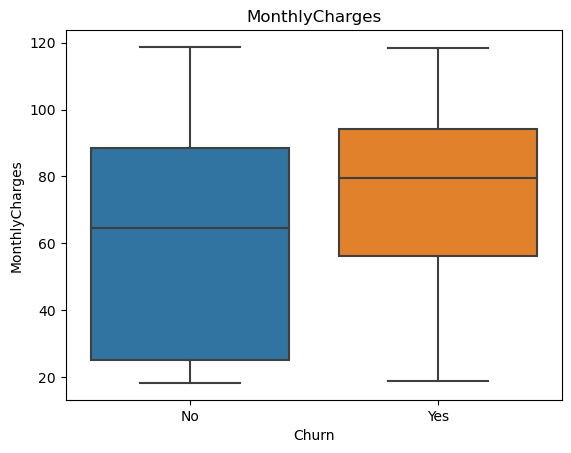

In [34]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title("MonthlyCharges")
plt.show()

In [35]:
# Churn vs Tenure
# Customers with shorter tenure tend to churn more frequently.

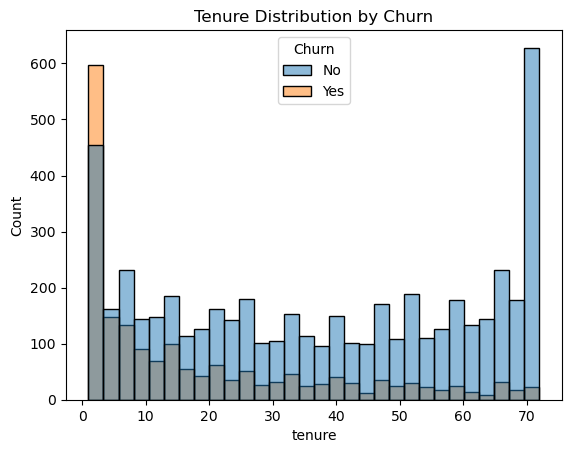

In [37]:
sns.histplot(data=df,x='tenure',hue='Churn',bins=30)
plt.title("Tenure Distribution by Churn")
plt.show()

In [38]:
# Internet Service vs Churn
# Fiber optic internet users show relatively higher churn rates.

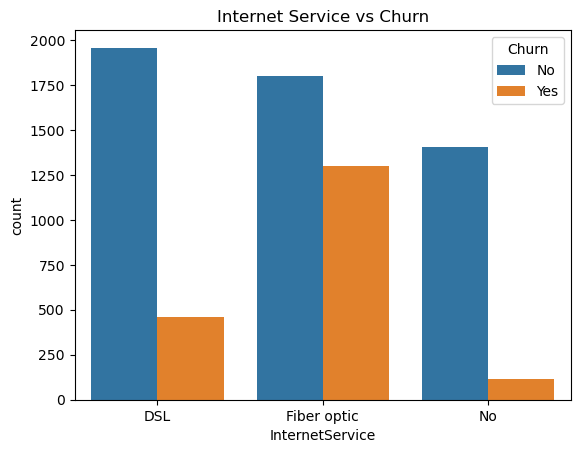

In [39]:
sns.countplot(x='InternetService',hue='Churn',data=df)
plt.title("Internet Service vs Churn")
plt.show()

In [45]:
print("Key Insights:")

print("1. Customers with month-to-month contracts have higher churn rates.")
print("2. Customers with higher monthly charges are more likely to churn.")
print("3. Customers with shorter tenure tend to churn more frequently.")
print("4. Certain payment methods such as electronic check show higher churn.")

Key Insights:
1. Customers with month-to-month contracts have higher churn rates.
2. Customers with higher monthly charges are more likely to churn.
3. Customers with shorter tenure tend to churn more frequently.
4. Certain payment methods such as electronic check show higher churn.
